# 🧬 DNA Platform: White-Space Analysis via DBSCAN

### Phase 1: Spatial Data Ingestion
Before we can cluster our "untapped" markets, we need to load our customer base and our existing operational boundaries. 
Since our raw customer data is in a CSV (standard pandas DataFrame), we must mathematically convert their Latitude and Longitude into a `GeoDataFrame` using `EPSG:4326` (Standard GPS coordinate system). This allows us to perform geometric intersections against the territory polygons.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

# Keep notebook output clean during prototyping
warnings.filterwarnings('ignore')

print("Loading datasets...")
# Use relative paths since we are inside the 'notebooks' folder
customer_df = pd.read_csv('../data/customer_touchpoints.csv')
territories_gdf = gpd.read_file('../data/territory_boundaries.geojson')

# Convert the flat CSV data into a spatial GeoDataFrame
customer_gdf = gpd.GeoDataFrame(
    customer_df,
    geometry=gpd.points_from_xy(customer_df.Longitude, customer_df.Latitude),
    crs="EPSG:4326"
)

print(f"Total customers loaded: {len(customer_gdf)}")
print(f"Total active territories loaded: {len(territories_gdf)}")
customer_gdf.head(3)

Loading datasets...
Total customers loaded: 1500
Total active territories loaded: 43


,ID,Type,Latitude,Longitude,Hub,geometry
0,CUST_0000,Independent Workshop,18.986814,73.016730,Mumbai,POINT (73.01673 18.98681)
1,CUST_0001,Independent Workshop,19.336965,73.009312,Mumbai,POINT (73.00931 19.33697)
2,CUST_0002,Independent Workshop,19.416972,73.512491,Mumbai,POINT (73.51249 19.41697)


### Phase 2: Geometric Exclusion (Finding the Whitespace)
A classic mistake in network expansion is clustering *all* customers, which leads to suggesting new dealers right next to existing ones (Cannibalization). 

To prevent this, we perform a **Spatial Join (`sjoin`)**. We test every single customer coordinate against the territory polygons. If a customer point falls `within` a polygon, we drop them. The remaining subset is our true "unserved" whitespace.

Match Check: True
Unique Served Customers: 587
Network Coverage Metrics:
Customers currently served: 587 (39.1%)
Unserved target customers: 913 (60.9%)


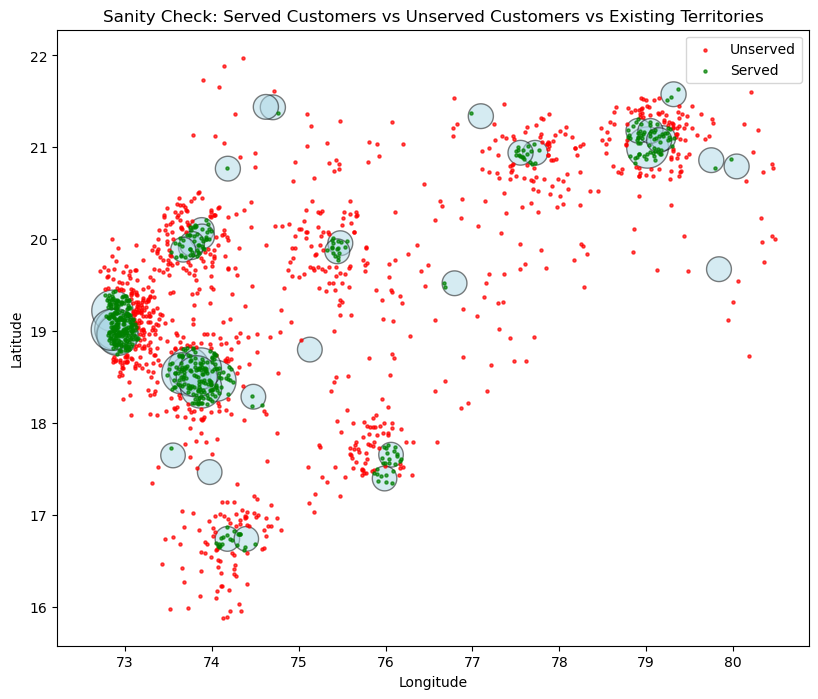

In [2]:
# Perform a Left Spatial Join
# 'how=left' keeps all customers. 'predicate=within' checks if the point is inside a polygon.
# If a customer is NOT inside a polygon, their 'index_right' column will be NaN.
joined_gdf = gpd.sjoin(customer_gdf, territories_gdf, how='left', predicate='within')

# Filter exclusively for the NaN values (Customers outside all dealer boundaries)
unserved_customers = joined_gdf[joined_gdf['index_right'].isna()].copy()
served_customers = joined_gdf[joined_gdf['index_right'].notnull()].drop_duplicates(subset=['ID_left']).copy()

# Clean up the dataframe by dropping the temporary join columns
unserved_customers = unserved_customers.drop(columns=['index_right'])
served_customers = served_customers.drop(columns=['index_right'])


# Calculate the network coverage metrics
total_cust = len(customer_gdf)
unserved_count = len(unserved_customers)
served_count = total_cust - unserved_count
served_count_by_df = len(served_customers)

print(f"Match Check: {served_count == served_count_by_df}")
print(f"Unique Served Customers: {served_count_by_df}")
print(f"Network Coverage Metrics:")
print(f"Customers currently served: {served_count} ({(served_count/total_cust)*100:.1f}%)")
print(f"Unserved target customers: {unserved_count} ({(unserved_count/total_cust)*100:.1f}%)")

# Let's plot a quick visual sanity check
fig, ax = plt.subplots(figsize=(10, 8))
territories_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
unserved_customers.plot(ax=ax, color='red', markersize=5, alpha=0.7, label='Unserved')
served_customers.plot(ax=ax, color='green', markersize=5, alpha=0.7, label='Served')
ax.set_title("Sanity Check: Served Customers vs Unserved Customers vs Existing Territories")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

### Phase 3: Density-Based Clustering (DBSCAN)
Now we hunt for the "Untapped Pockets". We need to find areas where at least **15 unserved customers** are grouped within a **25 km radius**. 

Because the Earth is a sphere, standard Euclidean distance (straight lines on a flat grid) will distort our distances. We must use the **Haversine metric**, which calculates the great-circle distance between two points on a globe. 

To use Haversine in `scikit-learn`, we must:
1. Convert all Latitude and Longitude coordinates from degrees to **radians**.
2. Convert our 25 km search radius ($\epsilon$) into radians by dividing it by the Earth's radius (approx. 6371 km).

Initializing DBSCAN Clustering & Post-Processing Engine...
✅ Successfully validated 9 distinct expansion pockets.


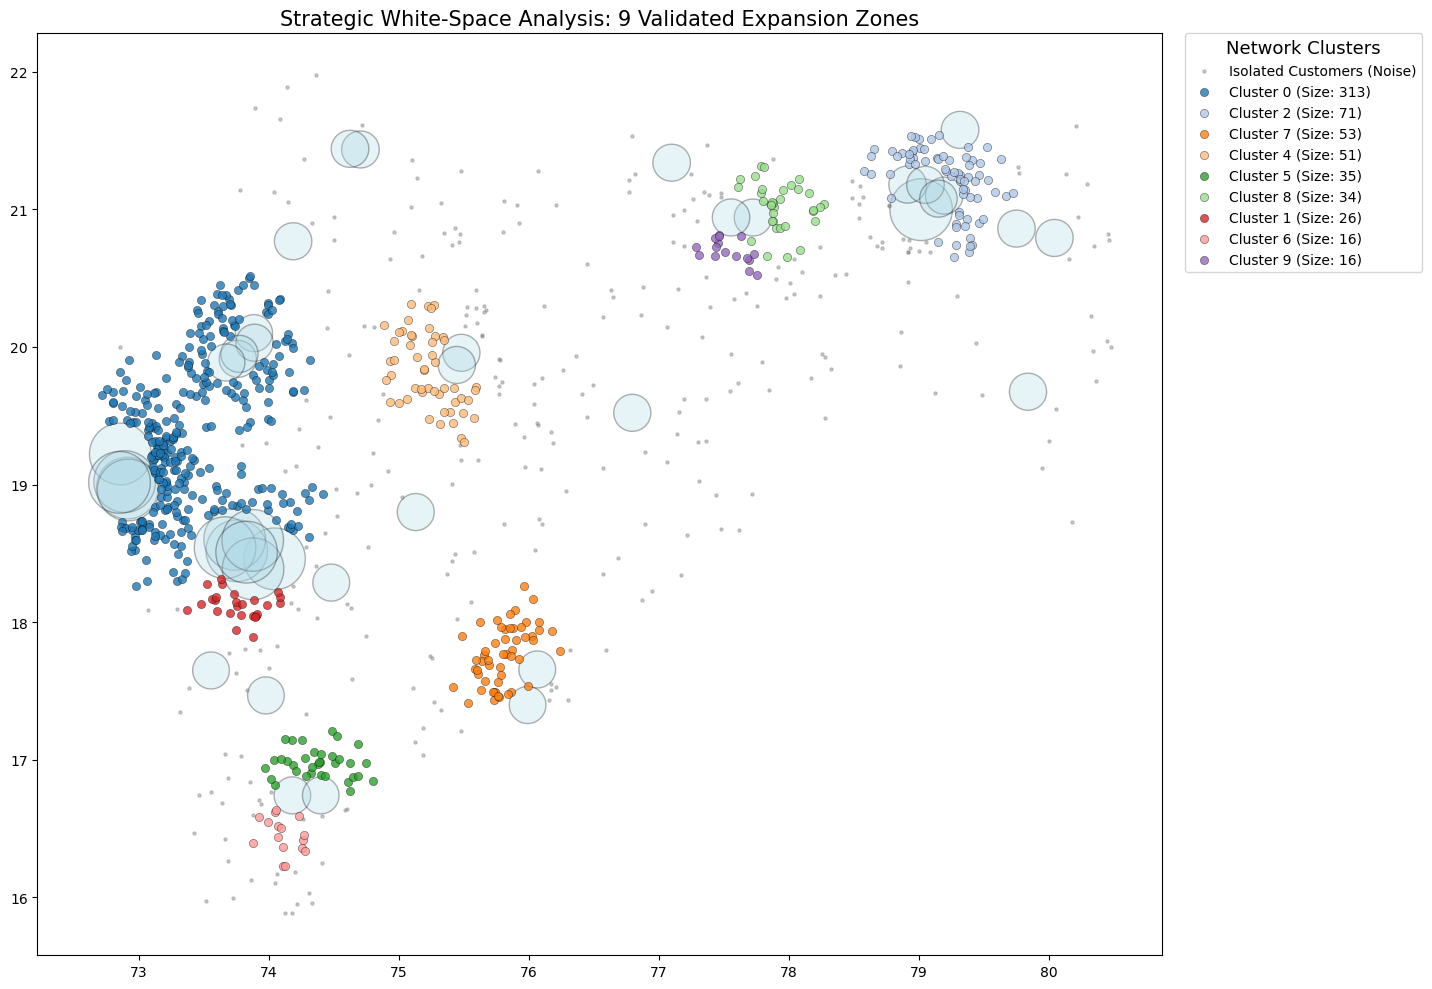

In [18]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

print("Initializing DBSCAN Clustering & Post-Processing Engine...")

# --- 1. SPATIAL CLUSTERING (DBSCAN) ---
# Convert coordinates to radians for the Haversine formula
coords = np.radians(unserved_customers[['Latitude', 'Longitude']])

# Business Hyperparameters
EARTH_RADIUS_KM = 6371.0
epsilon_km = 25.0
min_cluster_size = 15
epsilon_rad = epsilon_km / EARTH_RADIUS_KM

# Fit the Model
dbscan = DBSCAN(eps=epsilon_rad, min_samples=min_cluster_size, algorithm='ball_tree', metric='haversine')
unserved_customers['Cluster_Label'] = dbscan.fit_predict(coords)

# --- 2. POST-PROCESSING (Fixing Border Stealing) ---
# Separate clusters from noise
viable_clusters = unserved_customers[unserved_customers['Cluster_Label'] != -1].copy()
noise_points = unserved_customers[unserved_customers['Cluster_Label'] == -1].copy()

# Identify clusters that STILL have 15+ points after processing overlaps
cluster_counts = viable_clusters['Cluster_Label'].value_counts()
valid_cluster_labels = cluster_counts[cluster_counts >= min_cluster_size].index

# Overwrite dataframe to strictly enforce the business rule
viable_clusters = viable_clusters[viable_clusters['Cluster_Label'].isin(valid_cluster_labels)].copy()
final_counts = viable_clusters['Cluster_Label'].value_counts()

print(f"✅ Successfully validated {len(final_counts)} distinct expansion pockets.")

# --- 3. VISUALIZATION WITH DYNAMIC LEGENDS ---
fig, ax = plt.subplots(figsize=(14, 10))

# Layer 1: Background Territories & Noise
territories_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.3)
ax.scatter(noise_points['Longitude'], noise_points['Latitude'], 
           c='grey', s=5, alpha=0.4, label='Isolated Customers (Noise)')

# Layer 2: Loop through valid clusters for the legend
cmap = plt.get_cmap('tab20')
for idx, cluster_id in enumerate(final_counts.index):
    cluster_data = viable_clusters[viable_clusters['Cluster_Label'] == cluster_id]
    customer_count = final_counts[cluster_id]
    
    ax.scatter(cluster_data['Longitude'], cluster_data['Latitude'], 
               color=cmap(idx % 20), s=35, alpha=0.8, edgecolor='black', linewidth=0.3,
               label=f'Cluster {cluster_id} (Size: {customer_count})')

ax.set_title(f"Strategic White-Space Analysis: {len(final_counts)} Validated Expansion Zones", fontsize=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title="Network Clusters", title_fontsize='13')
plt.tight_layout()
plt.show()

Calculating Optimal RO Locations (Cluster Centroids)...
Refined Proposal: 9 highly profitable Retail Office locations.


,Cluster_Label,Proposed_RO_Lat,Proposed_RO_Lon,Target_Customers
0,0,19.358577,73.433211,313
1,2,21.212522,79.204740,71
2,7,17.766090,75.803367,53
3,4,19.819442,75.228322,51
4,5,16.975348,74.374461,35
5,8,21.023197,77.928498,34
6,1,18.124568,73.759838,26
7,6,16.451377,74.108630,16
8,9,20.695556,77.533206,16


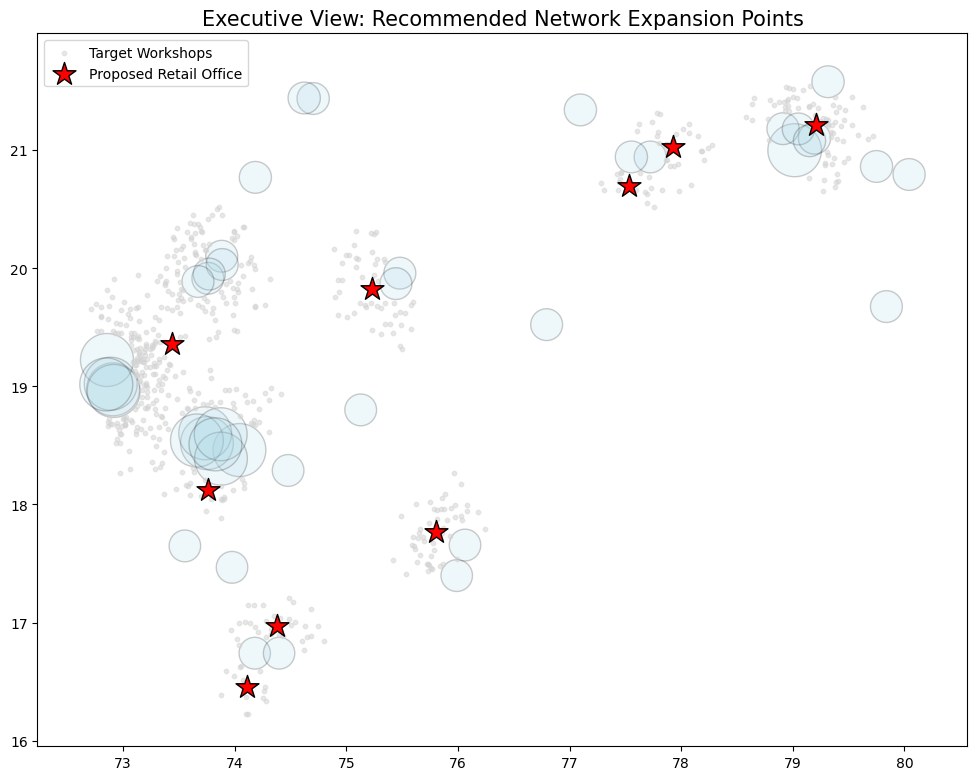

In [20]:
print("Calculating Optimal RO Locations (Cluster Centroids)...")

# --- 1. PROPOSAL GENERATION ---
# Calculate the geographic center of each validated cluster
centroids = viable_clusters.groupby('Cluster_Label')[['Latitude', 'Longitude']].mean().reset_index()
centroids = centroids.rename(columns={'Latitude': 'Proposed_RO_Lat', 'Longitude': 'Proposed_RO_Lon'})

# Merge the target customer count so management knows the exact value of each proposed location
centroids = centroids.merge(final_counts.rename('Target_Customers'), left_on='Cluster_Label', right_index=True)
centroids = centroids.sort_values(by='Target_Customers', ascending=False).reset_index(drop=True)

print(f"Refined Proposal: {len(centroids)} highly profitable Retail Office locations.")
display(centroids)

# --- 2. EXECUTIVE VISUALIZATION ---
fig, ax = plt.subplots(figsize=(12, 10))

# Layer 1: Background Territories
territories_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.2)

# Layer 2: Target Workshops (faded out to emphasize the centroids)
ax.scatter(viable_clusters['Longitude'], viable_clusters['Latitude'], 
           c='lightgrey', s=10, alpha=0.5, label='Target Workshops')

# Layer 3: Proposed RO Locations
ax.scatter(centroids['Proposed_RO_Lon'], centroids['Proposed_RO_Lat'], 
           color='red', marker='*', s=300, edgecolor='black', zorder=5, label='Proposed Retail Office')

ax.set_title("Executive View: Recommended Network Expansion Points", fontsize=15)
plt.legend(loc='upper left')
plt.show()

In [21]:
# Export the ML proposals to your data folder
centroids.to_csv('../data/proposed_ro_locations.csv', index=False)
print("Exported proposals to CSV for the web app!")

Exported proposals to CSV for the web app!
